In [348]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import chi2, norm

# Stochastic Simulation

## Exercise 1

## 1.1

### (a)

In [349]:
def LCG(x0, a, c, M, iter): 
    x = x0 
    Numbers = [x/M]
    for i in range(iter):
        x = (a*x + c) % M 
        U = x/M
        Numbers.append(U)
    return Numbers

In [350]:
# Test 1 
x0 = 3 
M = 16 
a = 5 
c = 1
iter = 16
LCG(x0, a, c, M, iter)

[0.1875,
 0.0,
 0.0625,
 0.375,
 0.9375,
 0.75,
 0.8125,
 0.125,
 0.6875,
 0.5,
 0.5625,
 0.875,
 0.4375,
 0.25,
 0.3125,
 0.625,
 0.1875]

In [351]:
# BAD example 
x0 = 3 
M = 16 
a = 5 
c = 1
iter = 10000 
RN = LCG(x0, a, c, M, iter)


In [352]:
# GOOD example 
x0 = 3 
M = 2**32 
a = 1203515245
c = 12345
iter = 10000 
RN = LCG(x0, a, c, M, iter)

In [353]:
RN

[6.984919309616089e-10,
 0.8406485617160797,
 0.7126281692180783,
 0.6703997845761478,
 0.9821126086171716,
 0.7774873180314898,
 0.045064297737553716,
 0.3323677801527083,
 0.36059573176316917,
 0.4589076992124319,
 0.05003916868008673,
 0.35361378407105803,
 0.9716593825723976,
 0.8731706896796823,
 0.5166646346915513,
 0.4036407698877156,
 0.06340551073662937,
 0.7885474972426891,
 0.3381747102830559,
 0.29911891696974635,
 0.6409818117972463,
 0.26570968981832266,
 0.4405754741746932,
 0.7423499659635127,
 0.1623214732389897,
 0.6339865196496248,
 0.5228184091392905,
 0.7657862617634237,
 0.4438438580837101,
 0.6033644350245595,
 0.8428721793461591,
 0.4294794839806855,
 0.3854911259841174,
 0.9341037794947624,
 0.03406784520484507,
 0.06833406491205096,
 0.874475791817531,
 0.8358476785942912,
 0.6860925157088786,
 0.13604029500856996,
 0.9771142217796296,
 0.01809811405837536,
 0.17500643827952445,
 0.44256211584433913,
 0.27812106697820127,
 0.06393418554216623,
 0.9766585261095

(array([ 985.,  902.,  977., 1061., 1017., 1029., 1027.,  949., 1012.,
        1042.]),
 array([6.98491931e-10, 9.99890394e-02, 1.99978078e-01, 2.99967117e-01,
        3.99956156e-01, 4.99945194e-01, 5.99934233e-01, 6.99923272e-01,
        7.99912311e-01, 8.99901349e-01, 9.99890388e-01]),
 <BarContainer object of 10 artists>)

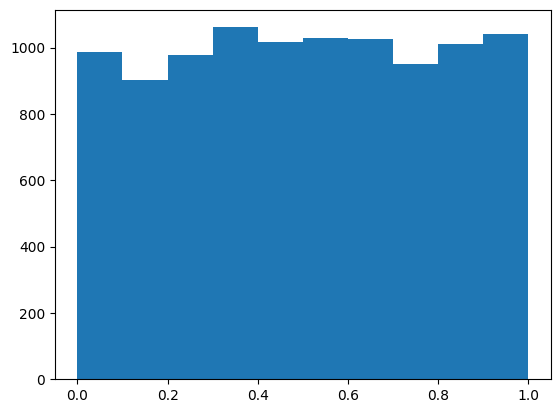

In [354]:
plt.hist(RN,10)

### (b)

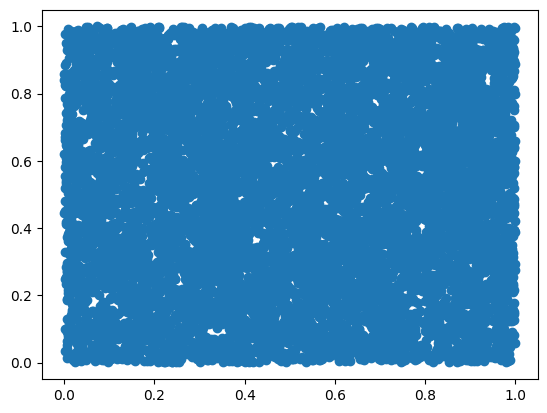

In [355]:
# Scatterplot 

plt.scatter(RN[:-1], RN[1:])

In [356]:
# Chi-squared test 

def T_chi_square(n_observed, n_expected, m): 
    n_classes = len(n_observed)
    T = np.sum((n_observed - n_expected)**2/n_expected)
    df = n_classes - 1 - m
    p_value = chi2.sf(T,df)
    return p_value

In [357]:
bins = 10
N = len(RN)
n_observed,_ = np.histogram(RN, bins)
n_expected = np.ones(bins) * (N/bins)
m = 0 

T_chi_square(n_observed, n_expected, m) #Small p-value, very unlikely that derivation so large if the data followed a uniform distribution 

np.float64(0.015356975221829942)

In [358]:
def ecdf(x,obs): 

    obs = np.array(obs)

    ecdf = np.sum(obs <= x)/len(obs)
    return ecdf

def uniform_cdf(x, a=0, b=1):
    if x < a:
        return 0.0
    elif x > b:
        return 1.0
    else:
        return (x - a) / (b - a)

def Kolmogorov_Smirnov(obs,m): 
    x = np.linspace(0,1,m)
    F_n = []
    F = []
    for val in x:
        F_n.append(ecdf(val, obs))
        F.append(uniform_cdf(val))
    D_n = np.max(abs(np.array(F_n)- np.array(F)))

    return D_n


In [359]:
m = 100
D_n = Kolmogorov_Smirnov(RN, m)
D_n

np.float64(0.015353010153530133)

In [360]:
# Adjusted test statistic 

n = len(RN)

(np.sqrt(n) + 0.12 + 0.11/np.sqrt(n))*D_n # Not good result see 16 

np.float64(1.537237027169991)

In [361]:
# Wald-Wolfowitz run test

def Wald_Wolfowitz(obs):
    median = np.median(obs)
    above_below = []
    for x in obs:
        if x > median:
            above_below.append(1)
        if x <= median: 
            above_below.append(0)
    
    n1 = np.sum(above_below)
    n2 = len(above_below) - n1 
    runs = 1 
    for i in range(1,len(above_below)):
        if above_below[i] != above_below[i-1]:
            runs += 1
    
    T = runs 
 

    mean = 2*n1*n2/(n1 + n2) +1 
    var = 2*(n1*n2*(2*n1*n2 -n1 - n2)/( (n1+n2)**2*(n1 + n2 -1)))
    z = (T - mean)/np.sqrt(var)
    
    p_values = 2*norm.sf(abs(z))
    return p_values
    


In [362]:
# run test 1
Wald_Wolfowitz(RN)

np.float64(0.3734664158078266)

In [363]:
def knuth(obs):
    obs = np.array(obs)
    n = len(obs)

    # --- Step 1: compute increasing runs ---
    lengths = []
    current_len = 1

    for i in range(1, n):
        if obs[i] > obs[i - 1]:
            current_len += 1
        else:
            lengths.append(current_len)
            current_len = 1

    

    R = np.zeros(6)
    for r in lengths:
        if r <= 5: 
            R[r-1] += 1 
        else: 
            R[5] += 1 
    
    A = np.array([
    [4529.4,  9044.9, 13568, 18091, 22615, 27892],
    [9044.9, 18097, 27139, 36187, 45234, 55789],
    [13568, 27139, 40721, 54281, 67852, 83685],
    [18091, 36187, 54281, 72414, 90470, 111580],
    [22615, 45234, 67852, 90470, 113262, 139476],
    [27892, 55789, 83685, 111580, 139476, 172860]
    ])

    B = np.array([
    [1/6],
    [5/24],
    [11/120],
    [19/720],
    [29/5040],
    [1/840]
    ])

    
    d = R - n*B.flatten()
    Z = (d.T @ A @ d) / (n - 6)
    


    
    df = 6
    p_value = chi2.sf(Z,df)
  
    return p_value
            
    

In [364]:
knuth(RN)

np.float64(0.5044695978895759)

In [365]:
def correlation_coef(obs,h):
    obs = np.array(RN)
    n= len(obs)
    c = np.sum(obs[:-h] * obs[h:]) / (n - h)

    mean = 0.25
    var = 7/(144*n)
    z = (c - mean)/np.sqrt(var)
    
    p_values = 2*norm.sf(abs(z))
    return p_values

In [366]:
correlation_coef(RN,1)

np.float64(0.00852412349889195)

In [367]:
correlation_coef(RN,3)

np.float64(0.0212339168393527)

### (c)

In [368]:
""" 
# GOOD example 
x0 = 3 
M = 2**32 
a = 1203515245
c = 12345
iter = 10000 
RN = LCG(x0, a, c, M, iter)
"""

' \n# GOOD example \nx0 = 3 \nM = 2**32 \na = 1203515245\nc = 12345\niter = 10000 \nRN = LCG(x0, a, c, M, iter)\n'

## 1.2 

In [369]:
RN_sys = np.random.rand(10000)


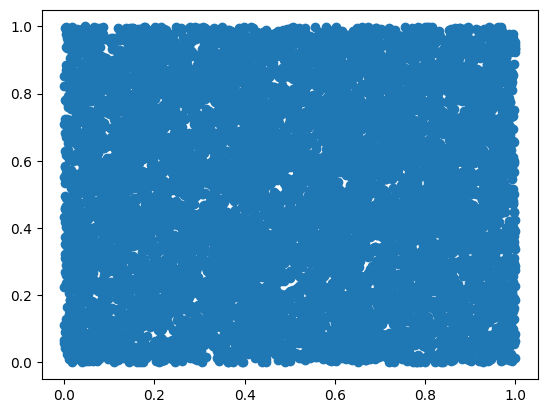

In [370]:
# Scatterplot 

plt.scatter(RN_sys[:-1], RN_sys[1:])

In [371]:
# Chi_square
bins = 10
N = len(RN_sys)
n_observed,_ = np.histogram(RN_sys, bins)
n_expected = np.ones(bins) * (N/bins)
m = 0 

T_chi_square(n_observed, n_expected, m)

np.float64(0.5509578627623721)

In [372]:
# Kolmogorov_Smirnov
m = 100
D_n = Kolmogorov_Smirnov(RN_sys, m)
D_n

# Adjusted test statistic 

n = len(RN_sys)

(np.sqrt(n) + 0.12 + 0.11/np.sqrt(n))*D_n 

np.float64(0.6963978733333381)

In [373]:
# Run test 1
Wald_Wolfowitz(RN_sys)

np.float64(0.2983157381983932)

In [374]:
# Run test 1

knuth(RN_sys)

np.float64(0.7057650097956247)

In [375]:
correlation_coef(RN_sys,1), correlation_coef(RN_sys,3)

(np.float64(0.00852412349889195), np.float64(0.0212339168393527))